# Final Project Results

## GCN Baseline

In [1]:
import sys
from pathlib import Path

# Allows importing from the project root
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))

Imports

In [2]:
import torch
import matplotlib.pyplot as plt

from src.gcn_baseline import GCN, accuracy, load_data, print_data_info, train

C:\Users\DeAndre\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import dataset (only Cora for now)

In [3]:
dataset, data = load_data("Cora")
print_data_info(dataset, data)

Processing...


Dataset: Cora
Nodes: 2708
Edges: 10556
Features per node: 1433
Classes: 7
Train nodes: 140
Validation nodes: 500
Test nodes: 1000


Done!


Constuct GCN Model

In [4]:
model = GCN(
    num_features=dataset.num_node_features,
    hidden_channels=16,
    num_classes=dataset.num_classes,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

model

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)

Training loop for the baseline

In [5]:
losses = []
val_accuracies = []

for epoch in range(1, 201):
    loss = train(model, data, optimizer)
    val_acc = accuracy(model, data, data.val_mask)

    losses.append(loss)
    val_accuracies.append(val_acc)

    if epoch == 1 or epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", round(loss, 4), "Val acc:", round(val_acc, 4))

Epoch: 1 Loss: 1.9457 Val acc: 0.202
Epoch: 20 Loss: 1.7222 Val acc: 0.664
Epoch: 40 Loss: 1.315 Val acc: 0.736
Epoch: 60 Loss: 0.9473 Val acc: 0.764
Epoch: 80 Loss: 0.695 Val acc: 0.772
Epoch: 100 Loss: 0.5266 Val acc: 0.788
Epoch: 120 Loss: 0.4813 Val acc: 0.798
Epoch: 140 Loss: 0.3943 Val acc: 0.79
Epoch: 160 Loss: 0.3856 Val acc: 0.782
Epoch: 180 Loss: 0.3377 Val acc: 0.788
Epoch: 200 Loss: 0.2953 Val acc: 0.786


Final accuracy for the GCN baseline

In [6]:
train_acc = accuracy(model, data, data.train_mask)
val_acc = accuracy(model, data, data.val_mask)
test_acc = accuracy(model, data, data.test_mask)

print("GCN results")
print("Train accuracy:", round(train_acc, 4))
print("Validation accuracy:", round(val_acc, 4))
print("Test accuracy:", round(test_acc, 4))

GCN results
Train accuracy: 1.0
Validation accuracy: 0.786
Test accuracy: 0.801


Plots

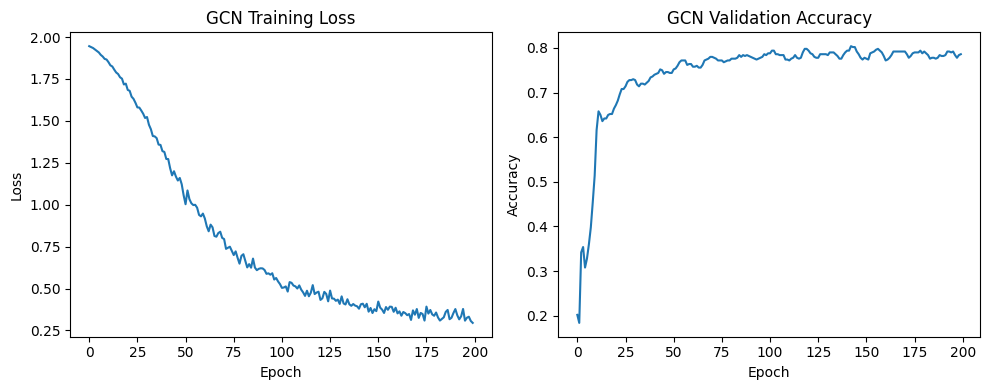

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("GCN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title("GCN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()